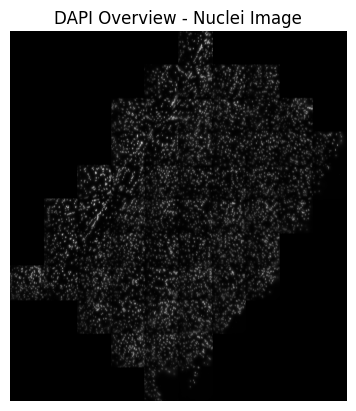

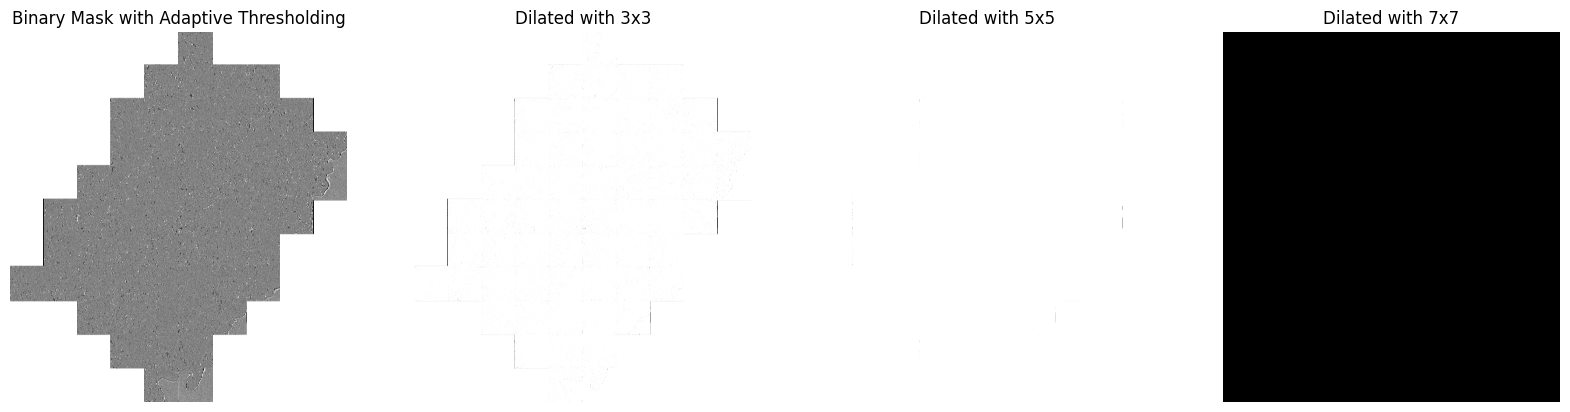

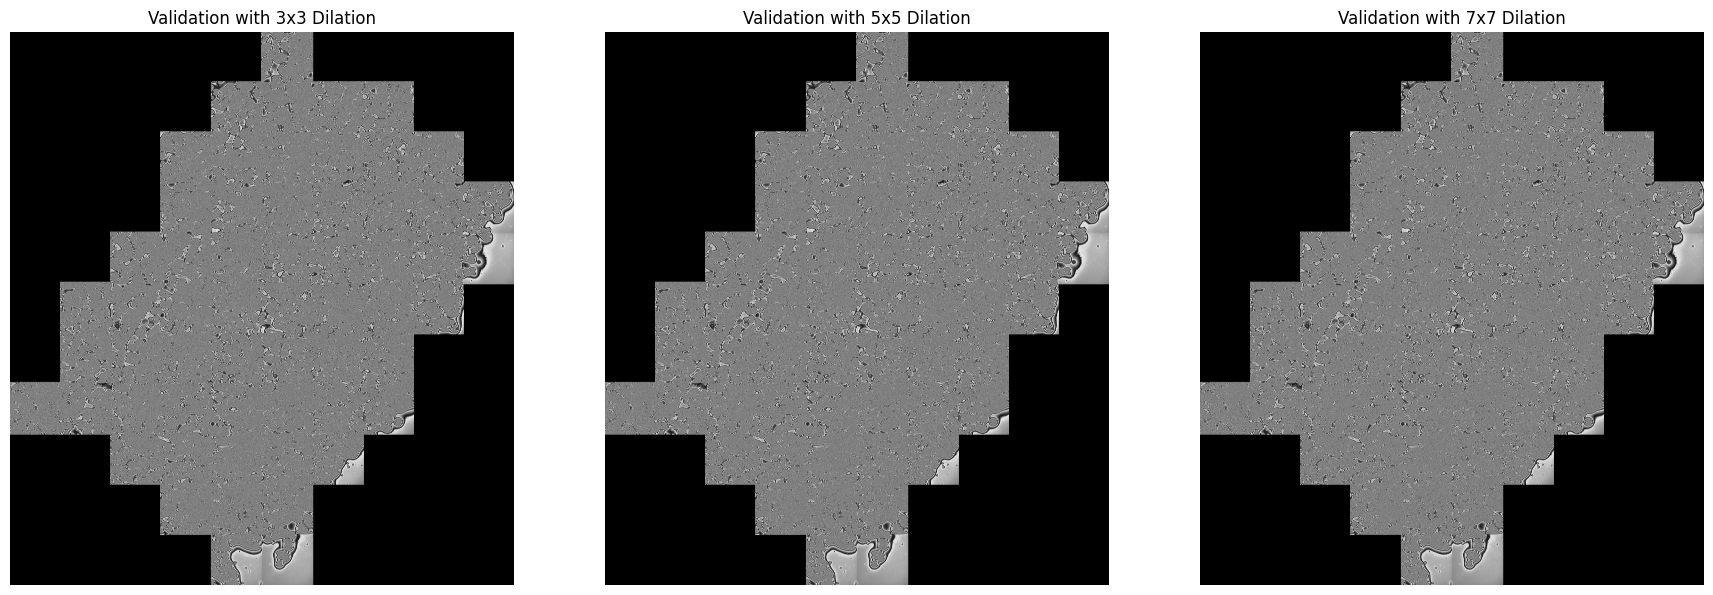

In [7]:
import cv2
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

# Path to the DAPI image file
image_path = "/kaggle/input/allen-merfish/Allen_MERFISH/DAPI_Overview.tif"

# Load the DAPI image
dapi_image = iio.imread(image_path)

# Display the original DAPI image
plt.imshow(dapi_image, cmap="gray")
plt.title("DAPI Overview - Nuclei Image")
plt.axis("off")
plt.show()

# Convert to grayscale (if needed)
if len(dapi_image.shape) == 3:
    gray_image = cv2.cvtColor(dapi_image, cv2.COLOR_RGB2GRAY)
else:
    gray_image = dapi_image

# Ensure the grayscale image is of type uint8
gray_image = gray_image.astype(np.uint8)

# Adaptive thresholding for binary mask
binary_mask = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Define structuring elements for dilation
kernel_3x3 = np.ones((3, 3), np.uint8)
kernel_5x5 = np.ones((5, 5), np.uint8)
kernel_7x7 = np.ones((7, 7), np.uint8)

# Apply dilation with different kernel sizes
dilated_3x3 = cv2.dilate(binary_mask, kernel_3x3, iterations=1)
dilated_5x5 = cv2.dilate(binary_mask, kernel_5x5, iterations=1)
dilated_7x7 = cv2.dilate(binary_mask, kernel_7x7, iterations=1)

# Display the dilation results
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(binary_mask, cmap='gray')
ax[0].set_title("Binary Mask with Adaptive Thresholding")
ax[1].imshow(dilated_3x3, cmap='gray')
ax[1].set_title("Dilated with 3x3")
ax[2].imshow(dilated_5x5, cmap='gray')
ax[2].set_title("Dilated with 5x5")
ax[3].imshow(dilated_7x7, cmap='gray')
ax[3].set_title("Dilated with 7x7")
for a in ax:
    a.axis("off")
plt.show()

# Ensure the binary masks are in the correct format (uint8)
dilated_3x3 = dilated_3x3.astype(np.uint8)
dilated_5x5 = dilated_5x5.astype(np.uint8)
dilated_7x7 = dilated_7x7.astype(np.uint8)

# Validate the results by multiplying the original grayscale image with the binary masks
validation_3x3 = cv2.bitwise_and(gray_image, gray_image, mask=dilated_3x3)
validation_5x5 = cv2.bitwise_and(gray_image, gray_image, mask=dilated_5x5)
validation_7x7 = cv2.bitwise_and(gray_image, gray_image, mask=dilated_7x7)

# Display the validation results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(validation_3x3, cmap='gray')
ax[0].set_title("Validation with 3x3 Dilation")
ax[1].imshow(validation_5x5, cmap='gray')
ax[1].set_title("Validation with 5x5 Dilation")
ax[2].imshow(validation_7x7, cmap='gray')
ax[2].set_title("Validation with 7x7 Dilation")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()
